In [ ]:
# Step 1: Install Required Libraries
!pip install -q scikit-learn matplotlib seaborn tensorflow pandas  # Install essential libraries quietly

In [ ]:
# Step 2: Import Libraries
import pandas as pd  # For data manipulation
import numpy as np  # For numerical operations
import matplotlib.pyplot as plt  # For visualizations
import seaborn as sns  # For enhanced visualizations

# Scikit-learn modules for preprocessing and evaluation
# Used for splitting data, scaling it, and checking how good your model is
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Random Forest classifier
# A tree-based machine learning model
from sklearn.ensemble import RandomForestClassifier

# TensorFlow/Keras for building the ANN model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# Step 3: Load Dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00519/heart_failure_clinical_records_dataset.csv"
df = pd.read_csv(url)  # Load dataset directly from UCI repository

print("Dataset Sample:")
print(df.head())  # Display the first few rows of the dataset

Dataset Sample:
    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582         0                 20   
1  55.0        0                      7861         0                 38   
2  65.0        0                       146         0                 20   
3  50.0        1                       111         0                 20   
4  65.0        1                       160         1                 20   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1  265000.00               1.9           130    1   
1                    0  263358.03               1.1           136    1   
2                    0  162000.00               1.3           129    1   
3                    0  210000.00               1.9           137    1   
4                    0  327000.00               2.7           116    0   

   smoking  time  DEATH_EVENT  
0        0     4            1  
1        0     6        

In [ ]:
# Step 4: Data Preprocessing
X = df.drop('DEATH_EVENT', axis=1)  # Features (independent variables)
y = df['DEATH_EVENT']  # Target variable (1 = death, 0 = alive)

scaler = StandardScaler()  # Initialize the standard scaler
X_scaled = scaler.fit_transform(X)  # Standardize features

# Split data into training and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [ ]:
# Step 5: Machine Learning - Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)  # Initialize Random Forest
rf.fit(X_train, y_train)  # Train model on training data
rf_preds = rf.predict(X_test)  # Make predictions on test data

print("\n Random Forest Classifier Report:")
print(classification_report(y_test, rf_preds))  # Performance report
print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds))  # Accuracy score


🔍 Random Forest Classifier Report:
              precision    recall  f1-score   support

           0       0.72      0.94      0.81        35
           1       0.86      0.48      0.62        25

    accuracy                           0.75        60
   macro avg       0.79      0.71      0.72        60
weighted avg       0.78      0.75      0.73        60

Random Forest Accuracy: 0.75


In [ ]:
# Step 6: ANN Model with Dropout + EarlyStopping
model = Sequential()
model.add(Dense(16, input_dim=X.shape[1], activation='relu'))  # Input layer with 16 neurons
model.add(Dropout(0.3))  # Dropout to prevent overfitting
model.add(Dense(8, activation='relu'))  # Hidden layer with 8 neurons
model.add(Dropout(0.2))  # Additional dropout
model.add(Dense(1, activation='sigmoid'))  # Output layer (binary classification)

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])  # Compile model

# Early stopping to avoid overfitting by monitoring validation loss
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the ANN model with early stopping
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=0  # Suppress training output
)

# Evaluate the ANN model on test data
loss, ann_acc = model.evaluate(X_test, y_test, verbose=0)  # Get accuracy and loss
ann_preds = (model.predict(X_test) > 0.5).astype("int32")  # Convert probabilities to binary output

print("\n🤖 Artificial Neural Network Report:")
print(classification_report(y_test, ann_preds))  # Detailed performance metrics
print("ANN Accuracy:", ann_acc)  # ANN accuracy

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step

🤖 Artificial Neural Network Report:
              precision    recall  f1-score   support

           0       0.70      0.94      0.80        35
           1       0.85      0.44      0.58        25

    accuracy                           0.73        60
   macro avg       0.77      0.69      0.69        60
weighted avg       0.76      0.73      0.71        60

ANN Accuracy: 0.7333333492279053


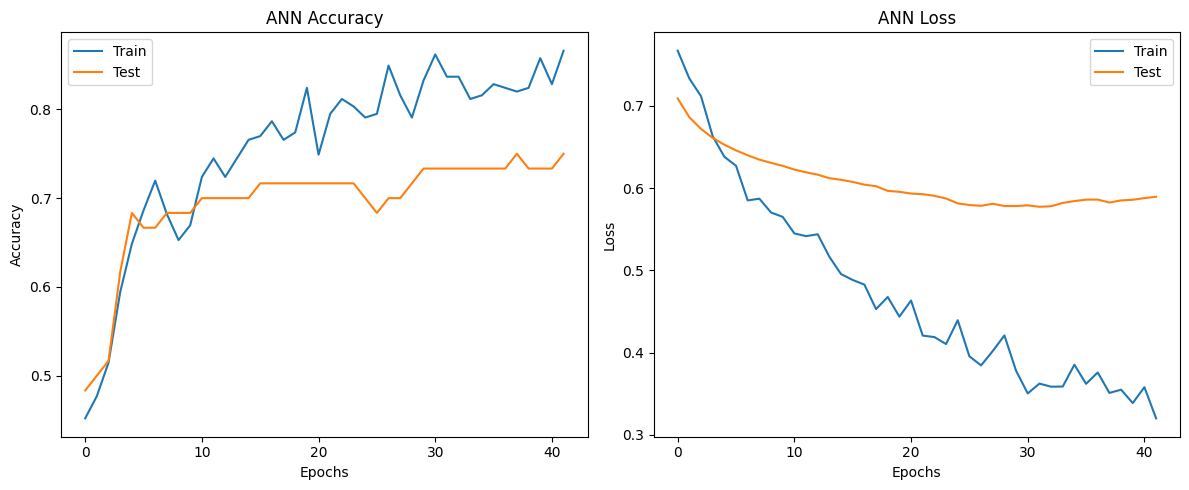

In [ ]:
# Step 7: Visualize ANN Training
plt.figure(figsize=(12,5))  # Set figure size

# Plot accuracy over epochs
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Test')
plt.title('ANN Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss over epochs
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Test')
plt.title('ANN Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()  # Display the training curves

In [ ]:
# Step 8: Take User Input & Predict
def get_user_input():
    """Prompt user to input patient data for prediction"""
    print("🔍 Please enter the following patient information:")

    # Collect and return user inputs as a list
    age = float(input("Age (years): "))
    anaemia = int(input("Anaemia (1 = Yes, 0 = No): "))
    cpk = float(input("Creatinine Phosphokinase (e.g., 250): "))
    diabetes = int(input("Diabetes (1 = Yes, 0 = No): "))
    ef = float(input("Ejection Fraction (e.g., 38): "))
    hbp = int(input("High Blood Pressure (1 = Yes, 0 = No): "))
    platelets = float(input("Platelets count (e.g., 263358.03): "))
    sc = float(input("Serum Creatinine (e.g., 1.1): "))
    ss = float(input("Serum Sodium (e.g., 130): "))
    sex = int(input("Sex (1 = Male, 0 = Female): "))
    smoking = int(input("Smoking (1 = Yes, 0 = No): "))
    time = int(input("Follow-up period in days (e.g., 4): "))

    return [age, anaemia, cpk, diabetes, ef, hbp, platelets, sc, ss, sex, smoking, time]

def predict_person(model, scaler, input_data):
    """Predict heart disease risk using trained ANN model"""
    input_data = np.array(input_data).reshape(1, -1)  # Reshape input for prediction
    input_scaled = scaler.transform(input_data)  # Apply same scaling as training
    prediction = model.predict(input_scaled)[0][0]  # Get probability from ANN

    print("\n Prediction Probability:", round(prediction, 3))
    if prediction >= 0.5:
        print("⚠  High Risk of Heart Disease")
    else:
        print("Low Risk of Heart Disease")

# Run the prediction by collecting user data and making inference
user_data = get_user_input()
predict_person(model, scaler, user_data)

🔍 Please enter the following patient information:
Age (years): 18
Anaemia (1 = Yes, 0 = No): 0
Creatinine Phosphokinase (e.g., 250): 250
Diabetes (1 = Yes, 0 = No): 0
Ejection Fraction (e.g., 38): 38
High Blood Pressure (1 = Yes, 0 = No): 0
Platelets count (e.g., 263358.03): 263358
Serum Creatinine (e.g., 1.1): 1.1
Serum Sodium (e.g., 130): 130
Sex (1 = Male, 0 = Female): 1
Smoking (1 = Yes, 0 = No): 0
Follow-up period in days (e.g., 4): 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step

🧠 Prediction Probability: 0.095
✅  Low Risk of Heart Disease


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
